Dataset Loaded: (20, 14)

Top Demand Vendors:
                           vendor_name       demand
12                   hopcoms_bengaluru  262575.1785
5                   malnad_nutri_foods  258002.8186
8                        tapcms_hassan  251702.7935
16  dakshina_kannada_exporters_network  247851.5961
9    sahaja_samrudha_organic_producers  243038.1020
19     mandya_organic_farmers_alliance  242583.8795
1              hubli_fresh_produce_co.  241187.6588
13        chikkamagaluru_spice_traders  239420.2891
0          sri_nanjundeshwara_apiaries  238458.3576
4            mysore_spices_&_herbs_hub  235294.7238

High Demand + High Risk Vendors: 2


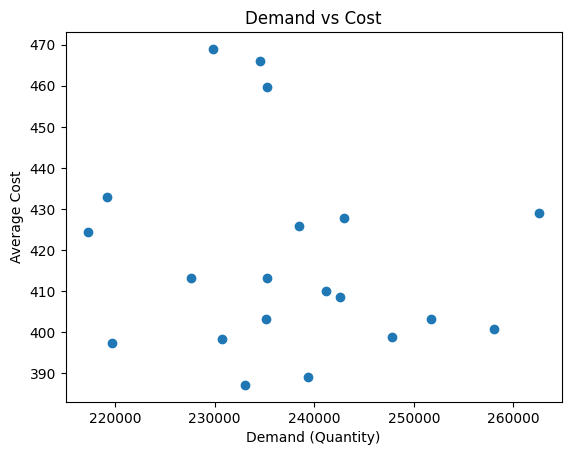

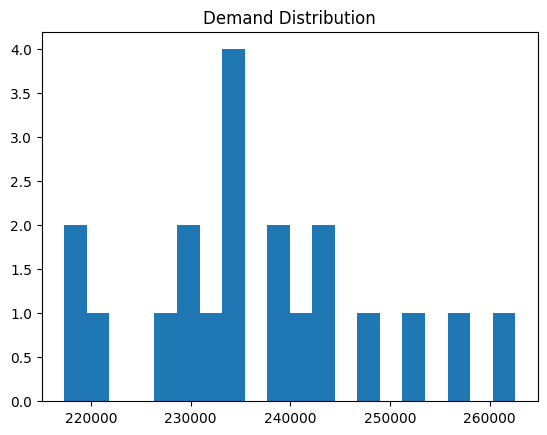

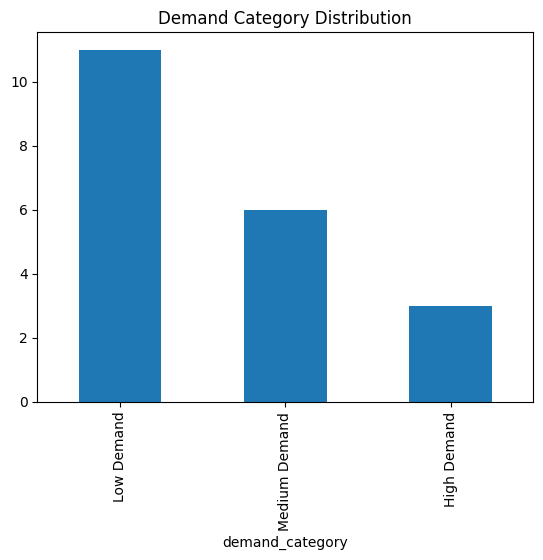


Demand Summary:
Total Vendors : 20
High Demand Vendors : 3
Low Demand Vendors : 11
Average Demand : 237130.70896999998

Day 23 Completed Successfully


In [2]:
# ==========================================================
# DAY 23 - DEMAND ANALYSIS & SEGMENTATION
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent

INPUT_FILE = PROJECT_ROOT / "03_processed_data/master_vendor_dataset.csv"
OUTPUT_FOLDER = PROJECT_ROOT / "03_processed_data/day23_outputs"

OUTPUT_FOLDER.mkdir(exist_ok=True)

df = pd.read_csv(INPUT_FILE)

print("Dataset Loaded:", df.shape)

# ----------------------------------------------------------
# 1. DEMAND METRIC
# ----------------------------------------------------------
# Using total_quantity as demand

df["demand"] = df["total_quantity"]

# ----------------------------------------------------------
# 2. DEMAND NORMALIZATION
# ----------------------------------------------------------

df["demand_score"] = (
    (df["demand"] - df["demand"].min()) /
    (df["demand"].max() - df["demand"].min())
)

# ----------------------------------------------------------
# 3. DEMAND CATEGORIES
# ----------------------------------------------------------

def demand_category(score):
    if score >= 0.7:
        return "High Demand"
    elif score >= 0.4:
        return "Medium Demand"
    else:
        return "Low Demand"

df["demand_category"] = df["demand_score"].apply(demand_category)

# ----------------------------------------------------------
# 4. TOP DEMAND VENDORS
# ----------------------------------------------------------

top_demand = df.sort_values("demand", ascending=False).head(10)

top_demand.to_csv(
    OUTPUT_FOLDER / "top_demand_vendors.csv",
    index=False
)

print("\nTop Demand Vendors:")
print(top_demand[["vendor_name", "demand"]])

# ----------------------------------------------------------
# 5. LOW DEMAND VENDORS
# ----------------------------------------------------------

low_demand = df.sort_values("demand").head(10)

low_demand.to_csv(
    OUTPUT_FOLDER / "low_demand_vendors.csv",
    index=False
)

# ----------------------------------------------------------
#CREATE RISK SCORE
# ----------------------------------------------------------

if "risk_score" not in df.columns:

    # Normalize defect
    df["defect_score"] = (
        (df["avg_defect"] - df["avg_defect"].min()) /
        (df["avg_defect"].max() - df["avg_defect"].min())
    )

    # Normalize cost
    df["cost_score"] = (
        (df["avg_cost"] - df["avg_cost"].min()) /
        (df["avg_cost"].max() - df["avg_cost"].min())
    )

    # Create risk score
    df["risk_score"] = (
        df["defect_score"] * 0.6 +
        df["cost_score"] * 0.4
    )
# ----------------------------------------------------------
# 6. HIGH DEMAND + HIGH RISK (CRITICAL)
# ----------------------------------------------------------

high_demand_risk = df[
    (df["demand_category"] == "High Demand") &
    (df["risk_score"] > df["risk_score"].mean())
]

high_demand_risk.to_csv(
    OUTPUT_FOLDER / "high_demand_high_risk.csv",
    index=False
)

print("\nHigh Demand + High Risk Vendors:", len(high_demand_risk))

# ----------------------------------------------------------
# 7. DEMAND VS COST VISUAL
# ----------------------------------------------------------

plt.figure()

plt.scatter(
    df["demand"],
    df["avg_cost"]
)

plt.xlabel("Demand (Quantity)")
plt.ylabel("Average Cost")
plt.title("Demand vs Cost")

plt.savefig(
    PROJECT_ROOT / "04_visualizations/demand_vs_cost.png"
)
plt.show()
plt.close()

# ----------------------------------------------------------
# 8. DEMAND DISTRIBUTION
# ----------------------------------------------------------

plt.figure()

plt.hist(df["demand"], bins=20)

plt.title("Demand Distribution")

plt.savefig(
    PROJECT_ROOT / "04_visualizations/demand_distribution.png"
)
plt.show()
plt.close()

# ----------------------------------------------------------
# 9. DEMAND CATEGORY DISTRIBUTION
# ----------------------------------------------------------

plt.figure()

df["demand_category"].value_counts().plot(kind="bar")

plt.title("Demand Category Distribution")

plt.savefig(
    PROJECT_ROOT / "04_visualizations/demand_category_distribution.png"
)
plt.show()
plt.close()

# ----------------------------------------------------------
# 10. KPI SUMMARY
# ----------------------------------------------------------

summary = {
    "Total Vendors": len(df),
    "High Demand Vendors": len(df[df["demand_category"] == "High Demand"]),
    "Low Demand Vendors": len(df[df["demand_category"] == "Low Demand"]),
    "Average Demand": df["demand"].mean()
}

print("\nDemand Summary:")
for k, v in summary.items():
    print(k, ":", v)

pd.DataFrame([summary]).to_csv(
    OUTPUT_FOLDER / "demand_kpi_summary.csv",
    index=False
)

# ----------------------------------------------------------
# 11. SAVE FINAL
# ----------------------------------------------------------

df.to_csv(
    OUTPUT_FOLDER / "demand_analysis_full.csv",
    index=False
)

print("\nDay 23 Completed Successfully")